# SVM with Linear Kernel — Raw Data
## Wisconsin Breast Cancer Dataset
### Pipeline: Load → 80/20 Split → Scale → Train SVM(linear) → Blue Visualizations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

sns.set_palette('Blues')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Blues(np.linspace(0.3, 0.9, 8)))

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load dataset
df = pd.read_csv('../../datasets/data.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Dataset shape: (569, 33)
Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN


In [3]:
# Drop 'id' column (not a feature) and 'Unnamed: 32' if present
if 'Unnamed: 32' in df.columns:
    df = df.drop(['id', 'Unnamed: 32'], axis=1)
else:
    df = df.drop(['id'], axis=1)

# Encode diagnosis: M = 1 (Malignant), B = 0 (Benign)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print(f"Class distribution:\n{df['diagnosis'].value_counts()}")
print(f"\nMalignant (1): {df['diagnosis'].sum()} cases")
print(f"Benign    (0): {len(df) - df['diagnosis'].sum()} cases")

Class distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64

Malignant (1): 212 cases
Benign    (0): 357 cases


In [4]:
# Separate features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# 80/20 train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Train size: 455 samples
Test size:  114 samples

Train class distribution:
diagnosis
0    285
1    170
Name: count, dtype: int64

Test class distribution:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [5]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized successfully.")

Features standardized successfully.


In [6]:
# Train SVM with linear kernel on RAW (imbalanced) data
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

# Predictions
y_pred = svm_linear.predict(X_test_scaled)
y_proba = svm_linear.predict_proba(X_test_scaled)[:, 1]

print("Model trained on RAW data.")

Model trained on RAW data.


In [7]:
# --- 6 Metrics ---

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Confusion Matrix → extract TN, FP, FN, TP for Specificity
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

roc_auc = roc_auc_score(y_test, y_proba)

# Display results
print("=" * 50)
print("SVM Linear Kernel — RAW Data Results")
print("=" * 50)
print(f"Accuracy:     {accuracy:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"F1-score:     {f1:.4f}")
print(f"Specificity:  {specificity:.4f}")
print(f"ROC-AUC:      {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(f"              Predicted")
print(f"              Neg    Pos")
print(f"Actual Neg    {tn:3d}   {fp:2d}")
print(f"       Pos    {fn:2d}   {tp:3d}")

SVM Linear Kernel — RAW Data Results
Accuracy:     0.9649
Precision:    1.0000
Recall:       0.9048
F1-score:     0.9500
Specificity:  1.0000
ROC-AUC:      0.9914

Confusion Matrix:
              Predicted
              Neg    Pos
Actual Neg     72    0
       Pos     4    38


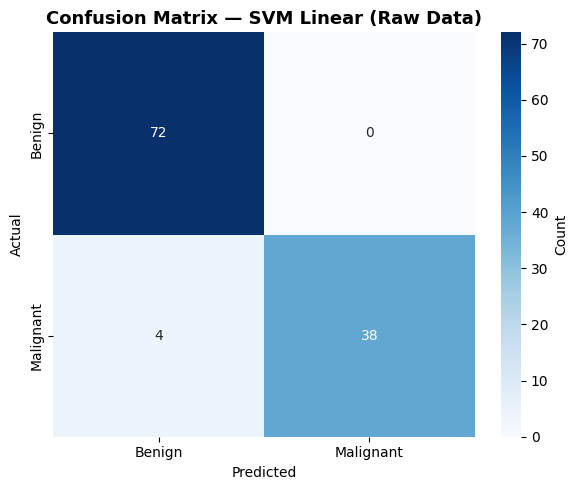

In [8]:
# Blue Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — SVM Linear (Raw Data)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

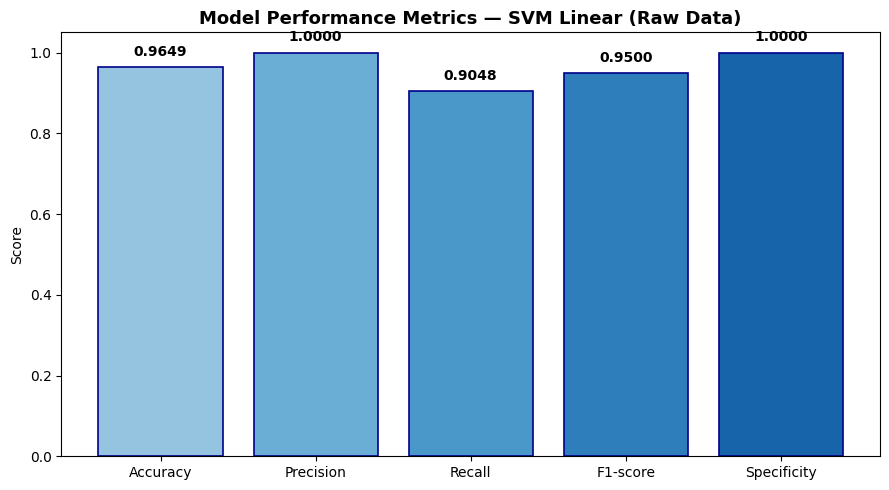

In [9]:
# Blue Metrics Bar Chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Specificity']
metrics_values = [accuracy, precision, recall, f1, specificity]
bar_colors = plt.cm.Blues([0.4, 0.5, 0.6, 0.7, 0.8])

plt.figure(figsize=(9, 5))
bars = plt.bar(metrics_names, metrics_values, color=bar_colors, edgecolor='darkblue', linewidth=1.2)
plt.ylim(0, 1.05)
plt.title('Model Performance Metrics — SVM Linear (Raw Data)', fontsize=13, fontweight='bold')
plt.ylabel('Score')

for bar, val in zip(bars, metrics_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

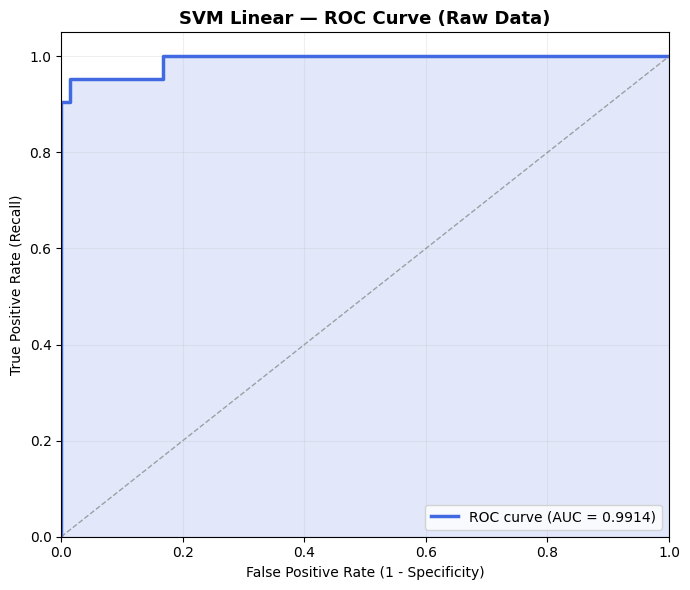

In [10]:
# Blue ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='royalblue', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.fill_between(fpr, tpr, alpha=0.15, color='royalblue')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('SVM Linear — ROC Curve (Raw Data)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()